In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import cv2
#from scipy.fft import fft, fftfreq
from numpy.fft import rfft, irfft, rfftfreq
from scipy.optimize import curve_fit

In [2]:
# Get video FPS
videos_path = r"C:\Users\Justine Elvena\Desktop\Acads\UPD\Sem4.1\Physics192\Inertial Balance\Vids"
fpsDict = {}
for filename in os.listdir(videos_path):
    if filename.endswith('.MOV'): 
        video_file_path = os.path.join(videos_path, filename)
        cap = cv2.VideoCapture(video_file_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()

        name, _ = os.path.splitext(filename)
        fpsDict[name] = fps
        #print(f"FPS of {filename}: {fps}")

print(fpsDict)

{'noload': 60.0, 'string1': 53.689119170984455, 'string2': 59.96907361416991, 'string3': 59.96627318718381, 'Test1': 59.9682467679746, 'Test2': 59.96796012815949, 'Test3': 59.96771796776921, 'unknown1': 59.965203943553064, 'unknown2': 59.96810207336523, 'unknown3(1)': 59.968520461699896, 'unknown3': 59.970311726867884}


In [3]:
def plot_csv_files(folder_path, x_col, y_col):
    plt.figure(figsize=(8,6))
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):  
            file_path = os.path.join(folder_path, filename)
            fpskey  = filename.split('_')[0]  
            
            # Read the CSV into a DataFrame
            df = pd.read_csv(file_path)
            
            # Plot with time on x-axis
            plt.plot(1/fpsDict[fpskey]*df[x_col], df[y_col], label=filename)

            # Add labels and legend
            plt.xlabel('Time (s)')
            plt.ylabel(y_col)
            #plt.title(f'Plots from {folder_path} files')
            plt.legend()
            plt.show()

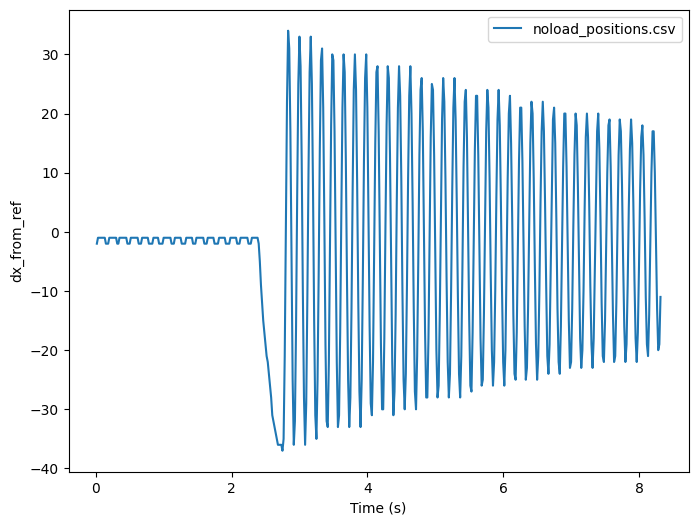

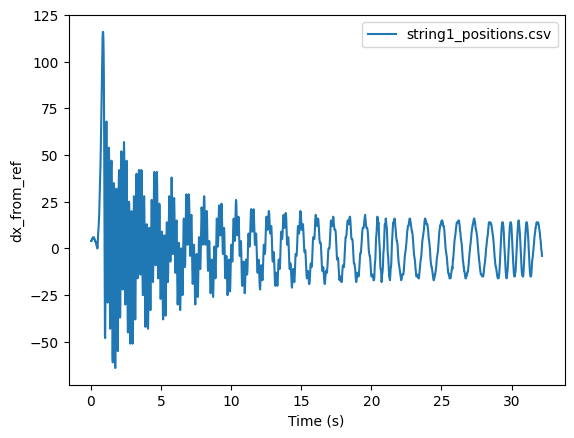

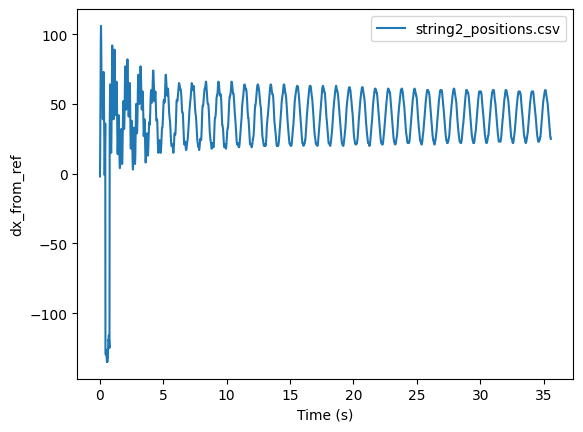

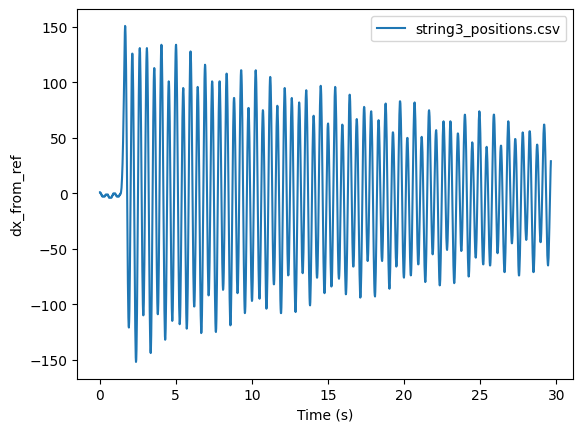

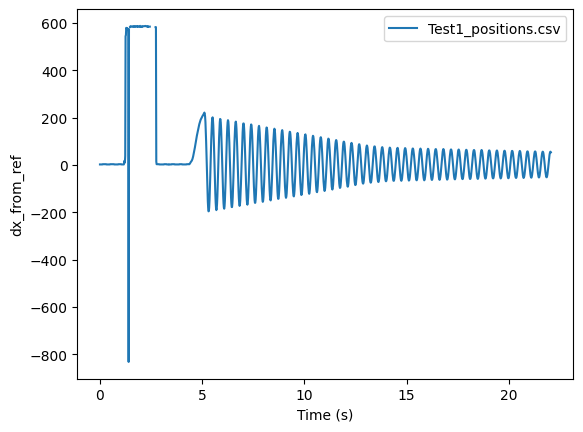

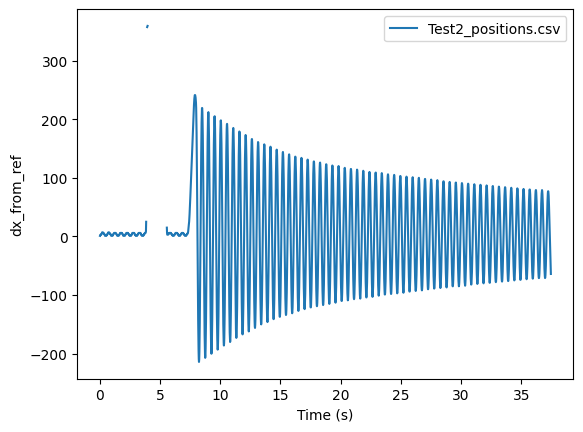

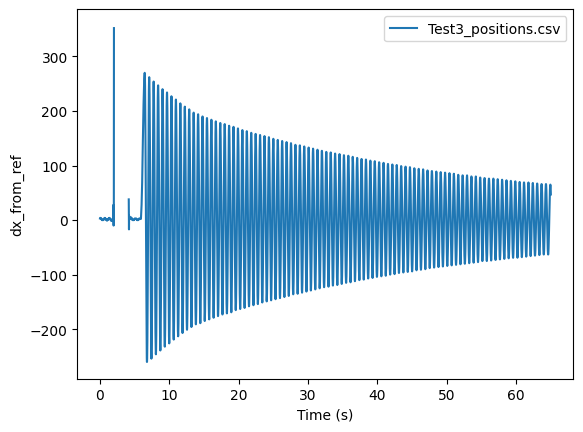

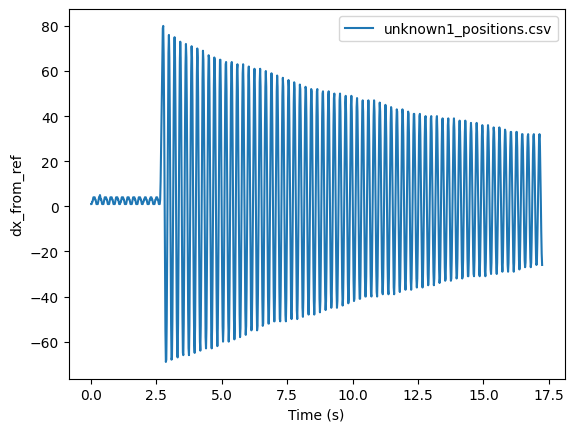

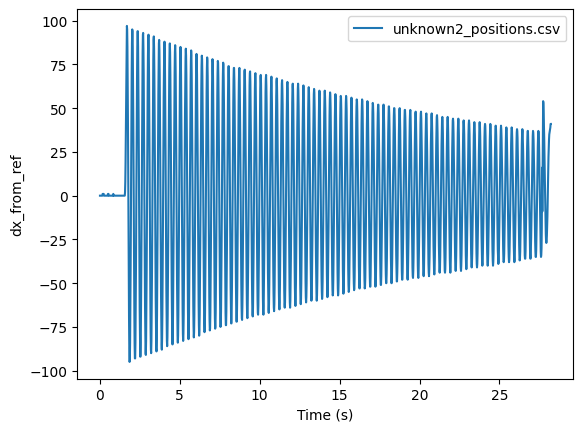

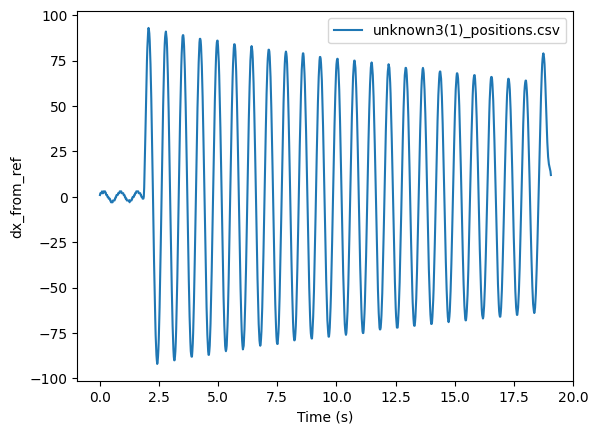

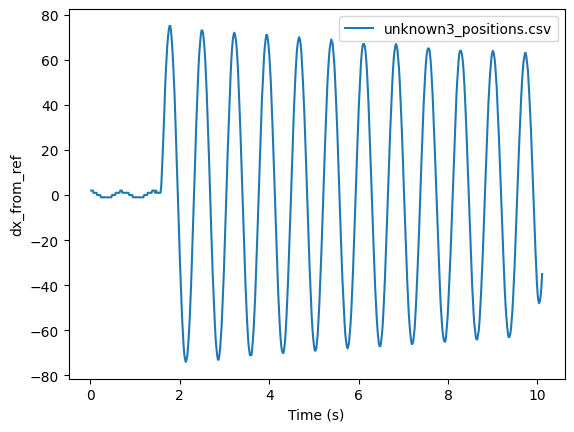

In [4]:
# csvs2 folder has the more accurate tracking data
plot_csv_files(r'./csvs2', 'frame', 'dx_from_ref')

## Calibrating the Inertial Balance ##

1. We first get the frequencies of each test run
2. Create linear regression for T^2 vs. M, which will become formula for masses to be placed in the balance

In [5]:
# Get the frequencies of the Test runs

def get_freq(csv_path, csv_name, start_time, end_time):
    # Look for csv file to be fft'ed
    matches = [files for files in os.listdir(csv_path) if files.startswith(csv_name)]

    if matches:
        file = matches[0]
    else:
        raise FileNotFoundError(f"No file starts with {csv_name}")
    csv_path = os.path.join(csv_path, file)

    df = pd.read_csv(csv_path)
    fps = fpsDict[csv_name]
    slice = df['dx_from_ref'][int(start_time*fps):int(end_time*fps)] # slice the data to the specified time range, using fps to convert seconds to frames
    signal = slice*np.hanning(len(slice)) # apply Hanning window to avoid spectral leakage

    # Perform fft
    fft_values = rfft(signal)
    freq_values = rfftfreq(len(signal), 1/fps)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(freq_values, abs(fft_values))
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude')

    plt.show()

    return freq_values, np.abs(fft_values)

    

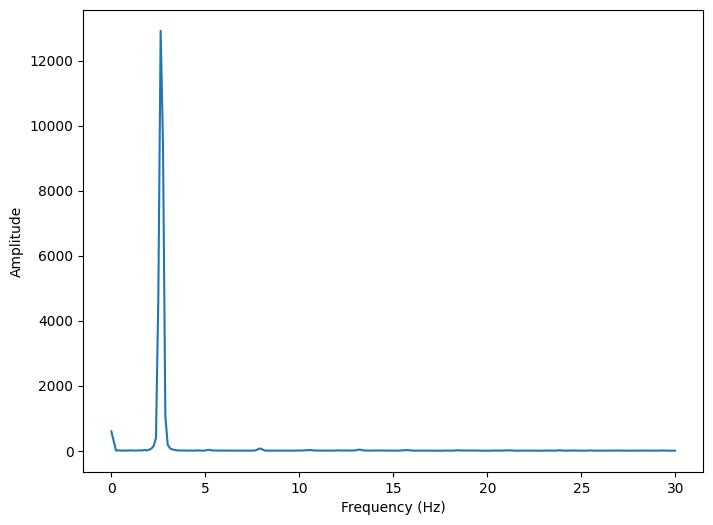

Dominant frequency: 2.623610796098889 Hz, corresponding to period T = 0.3811540955262589 s


In [6]:
# 268 g

freq_val, fft_val = get_freq(r'./csvs2', 'Test1', 7, 15)
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {1/freq_val[np.argmax(fft_val)]} s')
T1 = 1/freq_val[np.argmax(fft_val)]

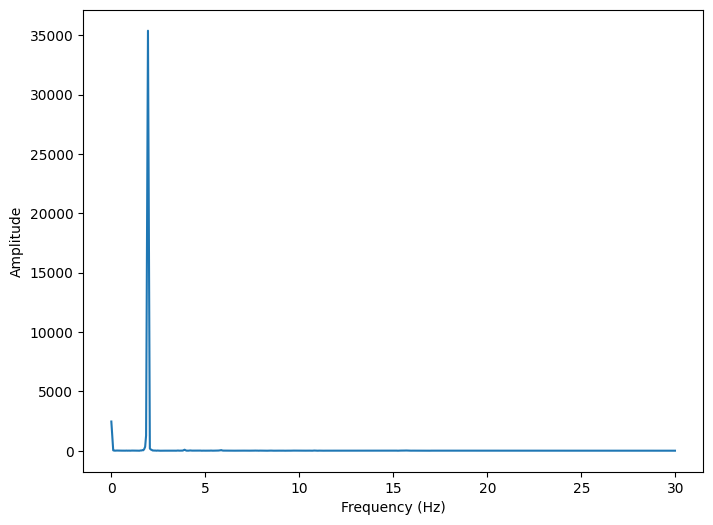

Dominant frequency: 1.9489587041651837 Hz, corresponding to period T = 0.5130945041897846 s


In [7]:
# 268 + 269 g

freq_val, fft_val = get_freq(r'./csvs2', 'Test2', 10, 30)
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {1/freq_val[np.argmax(fft_val)]} s')
T2 = 1/freq_val[np.argmax(fft_val)]

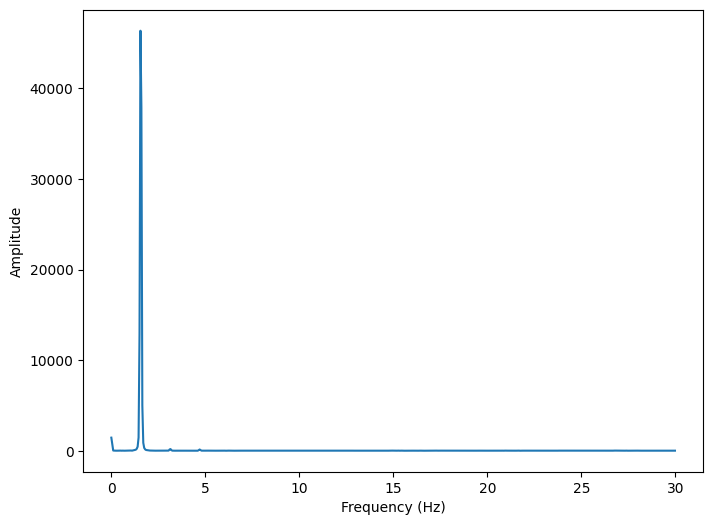

Dominant frequency: 1.5491660475007045 Hz, corresponding to period T = 0.6455085958108343 s


In [8]:
# 268 + 269 + 269 g

freq_val, fft_val = get_freq(r'./csvs2', 'Test3', 10, 30)
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {1/freq_val[np.argmax(fft_val)]} s')
T3 = 1/freq_val[np.argmax(fft_val)]

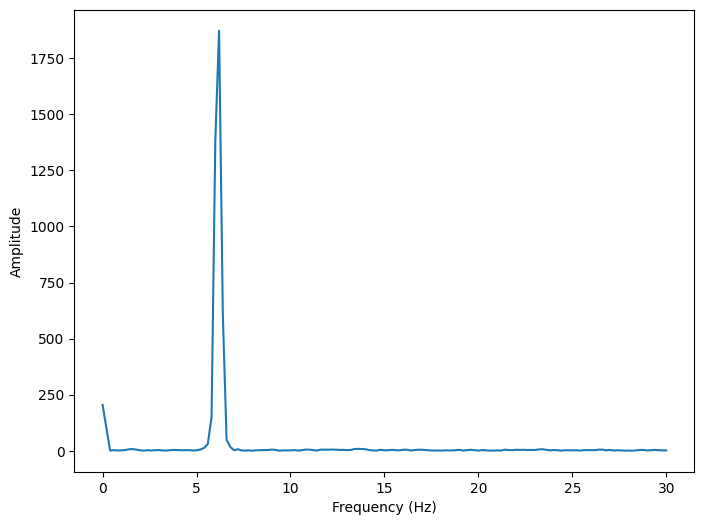

Dominant frequency: 6.2 Hz, corresponding to period T = 0.16129032258064516 s


In [9]:
# platform only

freq_val, fft_val = get_freq(r'./csvs2', 'noload', 3, 8)
T_platform = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_platform} s')

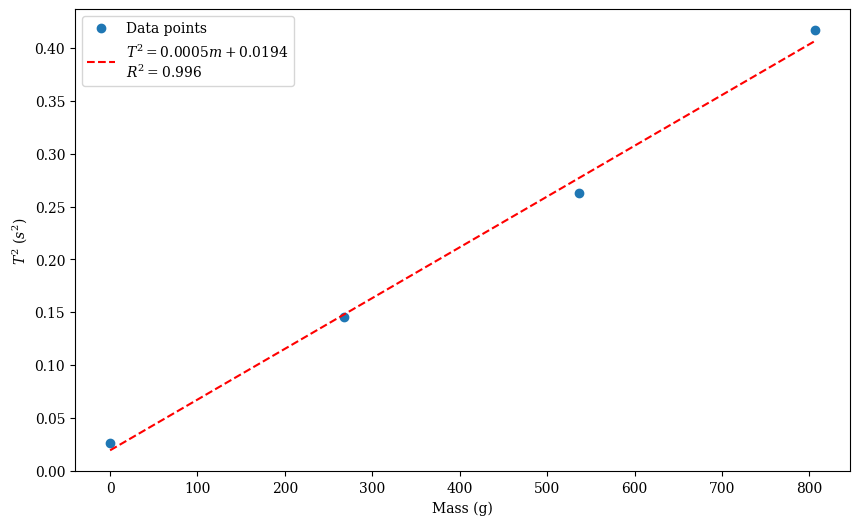

In [10]:
def line(x, m, b):
    return m*x + b

# Note that we are plotting T^2 vs mass of the load only!
knownTsquared = [T_platform**2, T1**2, T2**2, T3**2] 
masses = [0, 268, 268+269, 268+2*269] # NOTE: THE ACTUAL MASSES ARE 268, 269, AND 269, NOT 267, 268, 269

# Linear regression for the inertial balance
popt, _ = curve_fit(line, masses, knownTsquared)
 
 # Compue R^2
residuals = knownTsquared - line(np.array(masses), *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((knownTsquared - np.mean(knownTsquared))**2)
r_squared = 1 - (ss_res / ss_tot)


plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

plt.plot(masses, knownTsquared, 'o', label='Data points')
plt.plot(masses, line(np.array(masses), *popt), 'r--', label = rf"$T^2 = {popt[0]:.4f} m + {popt[1]:.4f}$" + "\n" + rf"$R^2 = {r_squared:.3f}$")
plt.xlabel('Mass (g)')
plt.ylabel(r'$T^2$ ($s^2$)')
plt.legend(fontsize=10, frameon=True)

plt.savefig('T_squared_vs_mass.png', dpi=300)
plt.show()


From the formula that relates the period and mass, $T^2 = \frac{2\pi L}{K} (m_{load} + m_{platform}/3)$, we see that $\text{slope} = \frac{2\pi L}{K}$ and $m_\text{platform} = 3\text{y-intercept}/\text{slope}$

In [11]:
print(f'From the regression line, mplatform is {3*popt[1]/popt[0]} g.')

From the regression line, mplatform is 121.52775017893346 g.


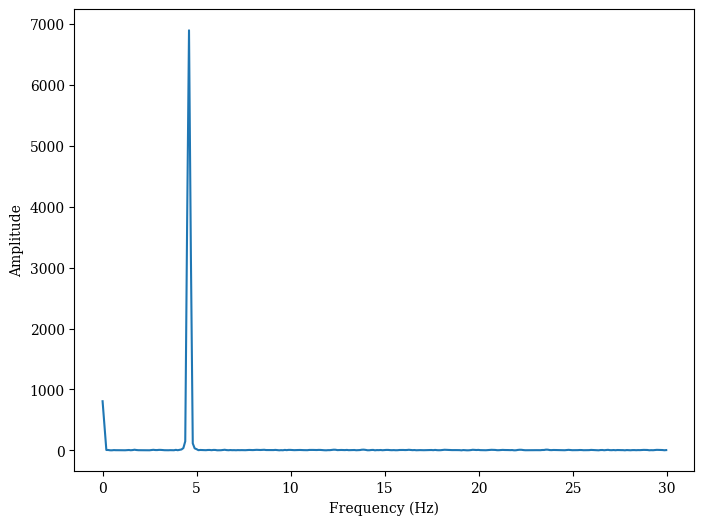

Dominant frequency: 4.597332302339068 Hz, corresponding to period T = 0.2175174501723993 s


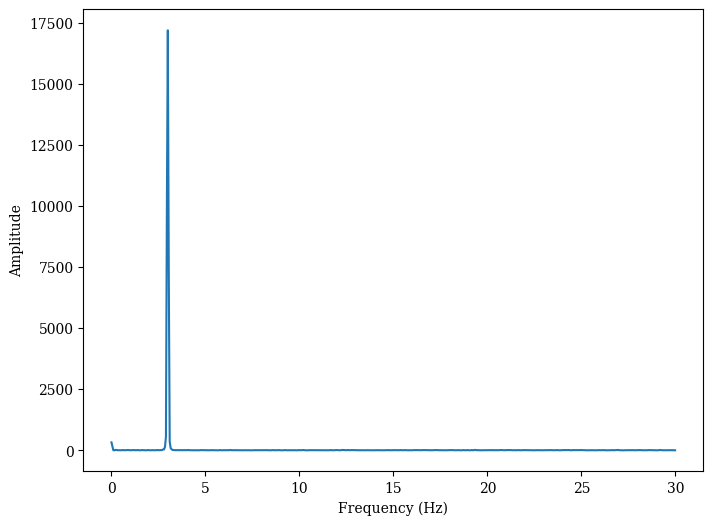

Dominant frequency: 2.9984051036682615 Hz, corresponding to period T = 0.33351063829787236 s


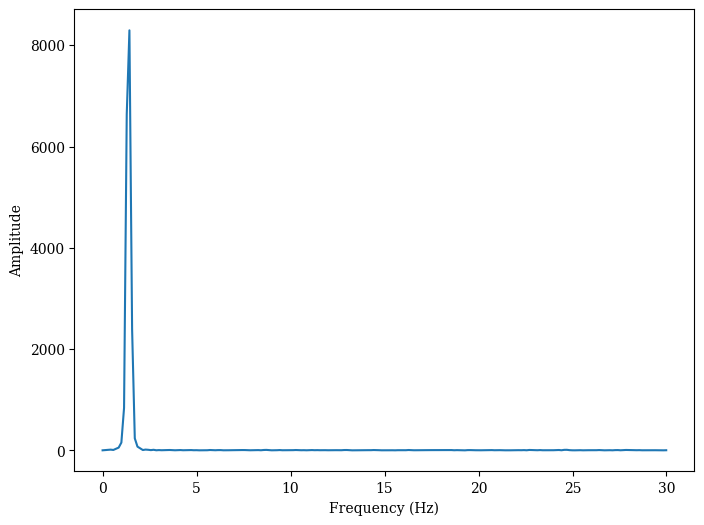

Dominant frequency: 1.4278645649254256 Hz, corresponding to period T = 0.7003465346534655 s


In [12]:
# Working on unknown masses
# First we find their frequencies and periods

freq_val, fft_val = get_freq(r'./csvs2', 'unknown1', 5, 15)
T_unknown1 = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_unknown1} s')

freq_val, fft_val = get_freq(r'./csvs2', 'unknown2', 5, 25)
T_unknown2 = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_unknown2} s')

freq_val, fft_val = get_freq(r'./csvs2', 'unknown3', 2, 9)
T_unknown3 = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_unknown3} s')

In [13]:
# Now working on the unknown masses

m1 = (T_unknown1**2 - popt[1])/popt[0] 
m2 = (T_unknown2**2 - popt[1])/popt[0] 
m3 = (T_unknown3**2 - popt[1])/popt[0] 

m1_err = abs(48 - m1)/48 * 100  
m2_err = abs(201 - m2)/201 * 100
m3_err = abs(998 - m3)/998 * 100

print(f'Mass 1 is {m1} g. This has an error of {m1_err} %')
print(f'Mass 2 is {m2} g. This has an error of {m2_err} %')
print(f'Mass 3 is {m3} g. This has an error of {m3_err} %')

Mass 1 is 58.04011136779323 g. This has an error of 20.916898682902563 %
Mass 2 is 191.16885394971558 g. This has an error of 4.891117437952446 %
Mass 3 is 981.1158992894161 g. This has an error of 1.6917936583751383 %


## Let's try to recover the mass of the 269 g weight when it was hung on a string ##

[]

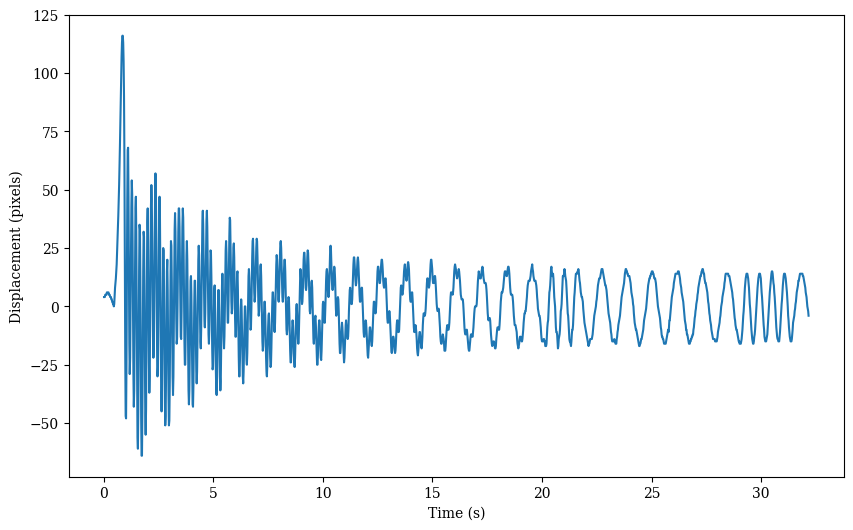

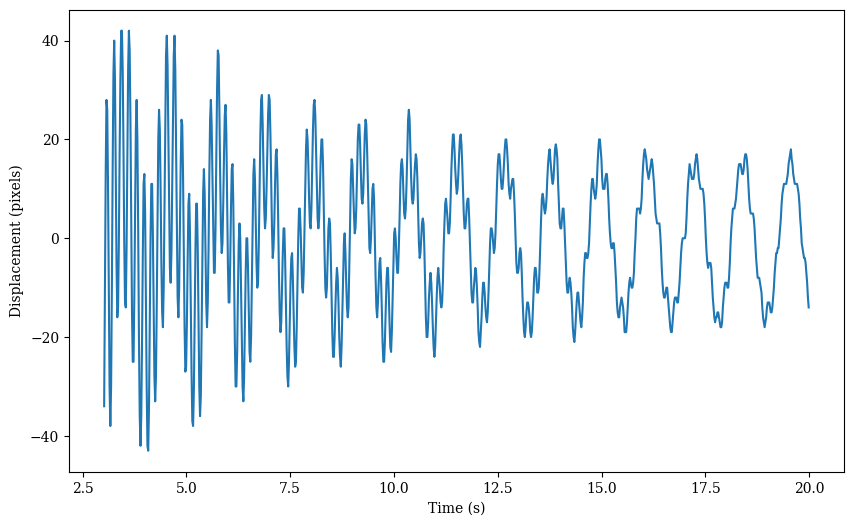

In [14]:
string1df = pd.read_csv('csvs2/string1_positions.csv')
string2df = pd.read_csv('csvs2/string2_positions.csv')

plt.figure(figsize=(10, 6))
plt.plot(string1df['frame']/fpsDict['string1'], string1df['dx_from_ref'], label='String 1')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (pixels)')
plt.plot()

plt.figure(figsize=(10, 6))
plt.plot(string1df['frame'][int(3*fpsDict['string1']):int(20*fpsDict['string1'])]/fpsDict['string1'], string1df['dx_from_ref'][int(3*fpsDict['string1']):int(20*fpsDict['string1'])], label='String 1')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (pixels)')
plt.plot()



It is obvious from the graphs that the system is not oscillating in a single frequency. It is interesting to note, however, that the high-frequency oscillations die out. This can also be seen in the videos. Let us try to recover the 268 mass of the load on the string by taking into account that the system is now a coupled oscillator. 

Let's look at the frequencies in the graph first

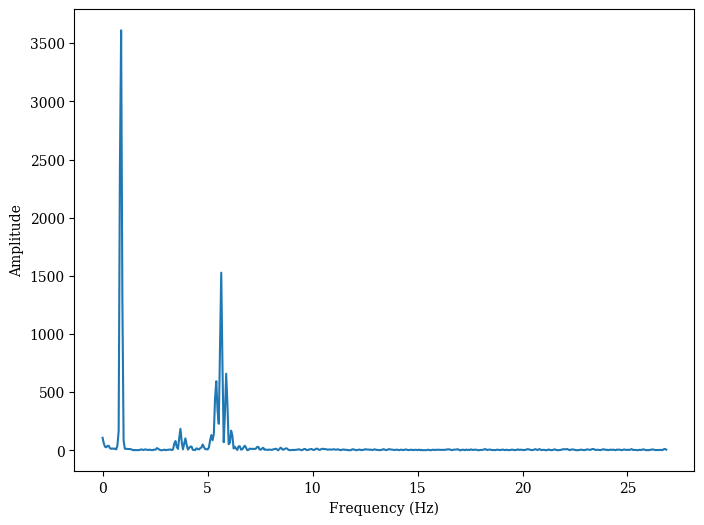

In [15]:
freq_val, fft_val = get_freq(r'./csvs2', 'string1', 3, 20)

If we naively use the dominant frequencies of the graph and use our $T^2$-$m$ relation, we get wrong answers:

In [16]:
T_string = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_string} s')
m_string = (T_string**2 - popt[1])/popt[0]

print(f'The recorded mass of the 269g is {m_string} g.')

Dominant frequency: 0.8830447232069811 Hz, corresponding to period T = 1.1324454738467478 s
The recorded mass of the 269g is 2630.6526275401266 g.


In [17]:
# Find indices of the sorted FFT amplitudes (ascending order)
sorted_indices = np.argsort(fft_val)

# Pick the second largest spike
second_largest_idx = sorted_indices[-2]
f_string = freq_val[second_largest_idx]
T_string = 1/f_string
print(f'Dominant frequency: {f_string} Hz, corresponding to period T = {T_string} s')
m_string = (T_string**2 - popt[1])/popt[0]

print(f'The recorded mass of the 269g is {m_string} g.')

Dominant frequency: 0.8241750749931823 Hz, corresponding to period T = 1.2133344362643728 s
The recorded mass of the 269g is 3025.8755584094815 g.


In [18]:
# Find indices of the sorted FFT amplitudes (ascending order)
sorted_indices = np.argsort(fft_val)

# Pick the third largest spike because second spike is just due to peak width of 1st spike
third_largest_idx = sorted_indices[-3]
f_string = freq_val[third_largest_idx]
T_string = 1/f_string
print(f'Dominant frequency: {f_string} Hz, corresponding to period T = {T_string} s')
m_string = (T_string**2 - popt[1])/popt[0]

print(f'The recorded mass of the 269g is {m_string} g.')

Dominant frequency: 5.6514862285246785 Hz, corresponding to period T = 0.17694460528855438 s
The recorded mass of the 269g is 24.70466296769372 g.


## A Different Model ##

1. We try to model the system as a coupled spring mass + pendulum

If we try to accurately model the system  by recognizing that they are coupled oscillators, the horizontal velocity of the pendulum bob, for small angular displacement $\theta$, is $\dot{x} + l\dot{\theta}$. Here $l$ is the length of the string from which the mass was hung and $x$ is the horizontal distance of the center of mass of the inertial balance platform from its equilibrium. Using $m_{\text{p}}$ and $m_{269}$ to denote the masses of the platform and pendulum bob, respectively, the total kinetic energy of the system is

$\begin{align}
    T &= \frac{1}{2}m_{\text{p}}\dot{x}^2 + \frac{1}{2}m_{269}(l^2\dot{\theta}^2 + \dot{x}^2 + 2\dot{x}l\dot{\theta}) \\
    &= \frac{1}{2}\begin{pmatrix}
        \dot{x} & \dot{\theta}
    \end{pmatrix} \begin{pmatrix}
        m_p + m_{269} & m_{269}l \\
        m_{269}l & m_{269} l^2
    \end{pmatrix} \begin{pmatrix}
        \dot{x} \\
        \dot{\theta}
    \end{pmatrix} \\
    &=\frac{1}{2}\begin{pmatrix}
        \dot{x} & \dot{\theta}
    \end{pmatrix} \tilde{T} \begin{pmatrix}
        \dot{x} \\
        \dot{\theta}
    \end{pmatrix}
\end{align}$

The potential energy is
$\begin{align}
    V &= \frac{1}{2}k x^2 + mgl(1-\cos(\theta))
\end{align}$

Note that $\frac{d^2V}{dx^2}|_{equilibrium}=k$, $\frac{d^2V}{d\theta^2}|_{equilibrium}=mgl$, so up to a second order Taylor expansion about the equilibrium points, the potential is

$\begin{align}
    V &\approx \frac{1}{2}kx^2 + \frac{1}{2}mgl\theta^2 \\
    &= \frac{1}{2}\begin{pmatrix}
        x & \theta
    \end{pmatrix} \begin{pmatrix}
        k & 0 \\
        0 & mgl
    \end{pmatrix} \begin{pmatrix}
        x \\
        \theta
    \end{pmatrix} = \frac{1}{2}\begin{pmatrix}
        x & \theta
    \end{pmatrix}\tilde{V}\begin{pmatrix}
        x \\
        \theta
    \end{pmatrix}
\end{align}$

Using the Euler-Lagrange equation $\frac{dL}{dq} - \frac{d}{dt}\frac{dL}{\dot{q}} =0$,

$\begin{align}
    \begin{pmatrix}
        \dot{x} & \dot{\theta}
    \end{pmatrix}[\tilde{V} \begin{pmatrix}
        x \\
        \theta
    \end{pmatrix} + \tilde{T} \begin{pmatrix}
        \ddot{x} \\
        \ddot{\theta}
    \end{pmatrix}] = 0
\end{align}$

Since we have an oscillatory motion, we expect $x = X \cos(\omega t -\delta)$ and $\theta = \Theta \cos(\omega t -\delta)$, so getting a nontrivial solution above amoutns to solving 

$\begin{align}
    \det(\tilde{V} - \omega^2 \tilde{T}) = 0.
\end{align}$


This gives the eigenfrequencies (here I renamed labels $m_p\to m_1$ and $m_{269}\to m_2$)

$\begin{align}
    \omega_{\pm} = \sqrt{\frac{\pm\sqrt{\left(g \left(m_1+m_2\right)+k l\right){}^2-4 g k l m_1}+g \left(m_1+m_2\right)+k l}{2l m_1}}.
\end{align}$

It could be that the peak frequencies we are getting from the Fourier transform are $\omega_{\pm}$. If only we know $m_1$, $k$, and $l$...

Since we treated the inertial balance as a spring mass system, its period has the relation $T = 2\pi\sqrt{\frac{m_1}{k}}$. Using $T_{platform} = 0.161s$,
$\begin{align}
    \sqrt{m_1/k} = 0.0256702 s
\end{align}$

------------------WE HAVE TOO MANY UNKNOWNS TO SOLVE IT EXACTLY (MAKE QUALITATIVE ARGUMENTS INSTEAD IN RND), BUT WE HAVE SHOWN HERE THAT WE WILL HAVE 2 MODE FREQUENCIES FOR A COUPLED SYSTEM LIKE IN THE EXPERIMENT, RENDERING THE CLAIM IN THE MODULE FALSE-------------------------------------


But what if we instead use the steady oscillations after long $t$ in string1.MOV?

[]

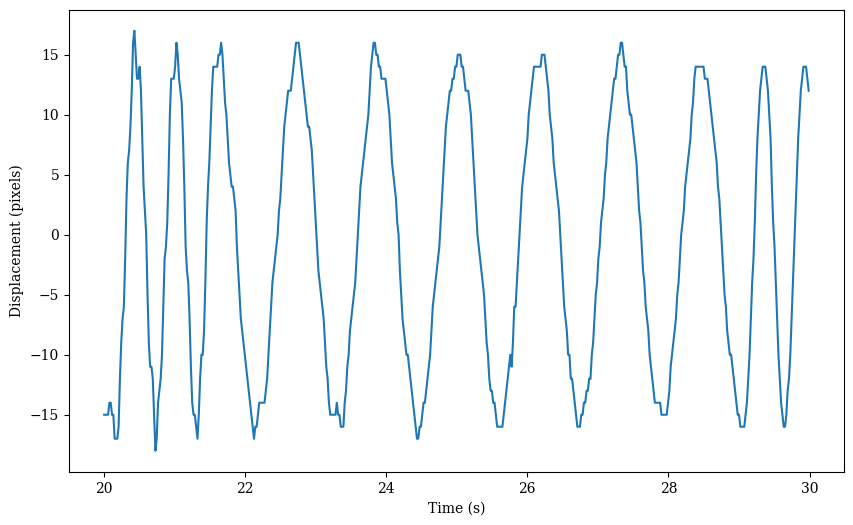

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(string1df['frame'][int(20*fpsDict['string1']):int(30*fpsDict['string1'])]/fpsDict['string1'], string1df['dx_from_ref'][int(20*fpsDict['string1']):int(30*fpsDict['string1'])], label='String 1')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (pixels)')
plt.plot()

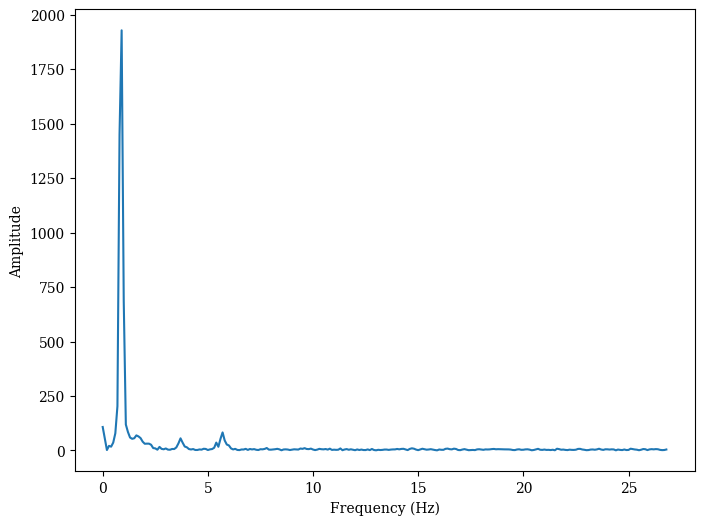

Dominant frequency: 0.8998176397371697 Hz, corresponding to period T = 1.1113362928649553 s
The recorded mass of the 269g is 2531.9979673105518 g.


In [20]:
freq_val, fft_val = get_freq(r'./csvs2', 'string1', 20, 30)
T_string = 1/freq_val[np.argmax(fft_val)]
print(f'Dominant frequency: {freq_val[np.argmax(fft_val)]} Hz, corresponding to period T = {T_string} s')
m_string = (T_string**2 - popt[1])/popt[0]

print(f'The recorded mass of the 269g is {m_string} g.')

It still gives bad answers!